In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, mean_squared_error, r2_score
from sklearn.tree import (DecisionTreeRegressor as DTR,
                          plot_tree,
                          export_text)
from matplotlib.pyplot import subplots
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import warnings
from sklearn.ensemble import GradientBoostingRegressor as GBR

In [7]:
airbnb_data = "C:\\Users\\rache\\Downloads\\cse2600\\airbnb_data\\Airbnb_data_cleaned2.csv" #path for csv

df = pd.read_csv(airbnb_data) #read in the data

In [8]:
df_no_outliers = df[df["price_outlier"] == 0]

In [28]:
train, test = train_test_split(df_no_outliers, train_size=64609, random_state=42)
#chose 64609 cuz thats 80%

# Split data into features (X) and target (y) for training and testing
y_train = train['price']
X_train = train.drop(['price'], axis=1)
#X_train = train.drop(['price', 'host Certification', 'beds', 'host acceptance rate'], axis=1)
y_test = test['price']
X_test = test.drop(['price'], axis=1)
#X_test = test.drop(['price', 'host Certification', 'beds', 'host acceptance rate'], axis=1)

Linear Regression R²: 0.38171930886273453
Linear Regression MSE: 6405.948471863867


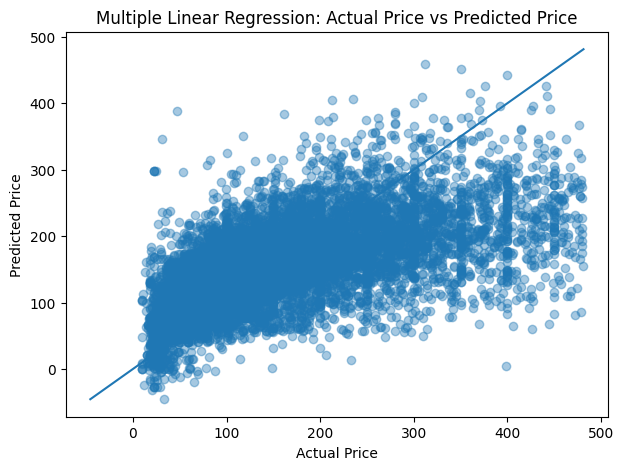

In [29]:
# Liner regression model

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)
mse_lr = mean_squared_error(y_test, pred_lr)
r2_lr = r2_score(y_test, pred_lr)

print("Linear Regression R²:", r2_lr)
print("Linear Regression MSE:", mse_lr)


# Scatter plot of Actual vs Predicted
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(y_test, pred_lr, alpha=0.4)

plt.title("Multiple Linear Regression: Actual Price vs Predicted Price")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

min_val = min(min(y_test), min(pred_lr))
max_val = max(max(y_test), max(pred_lr))
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()

In [27]:
lr = LinearRegression()
lr.fit(X_train, y_train)

train_pred = lr.predict(X_train)
test_pred = lr.predict(X_test)

print("Train MSE:", mean_squared_error(y_train, train_pred))
#print("Test MSE:", mean_squared_error(y_test, test_pred))

print("Train R2:", r2_score(y_train, train_pred))
#print("Test R2:", r2_score(y_test, test_pred))

Train MSE: 6405.767873596051
Train R2: 0.383279451615018


In [ ]:
import statsmodels.api as sm

X = df_no_outliers.drop(['price'], axis=1)
y = df_no_outliers['price']

# X is your feature matrix, y is your target
X = sm.add_constant(X)  # adds intercept term

model = sm.OLS(y, X).fit()
#print(model.summary())

p_values = model.pvalues
print(p_values)

const                         1.151787e-03
city                         2.792556e-226
guest favourite               4.695029e-48
host since                    5.507834e-29
host Certification            2.661552e-01
room_type                     0.000000e+00
host total listings count    3.280394e-128
total reviewers number        1.801714e-38
accommodates                  0.000000e+00
bathrooms                     8.416964e-07
bedrooms                     5.852374e-175
beds                          7.430364e-01
listing number               1.231119e-236
host response rate            1.753405e-29
host acceptance rate          9.711403e-02
sales                         1.143050e-06
area                          0.000000e+00
price_outlier                          NaN
dtype: float64


Random Forest MSE: 3643.8763265544676


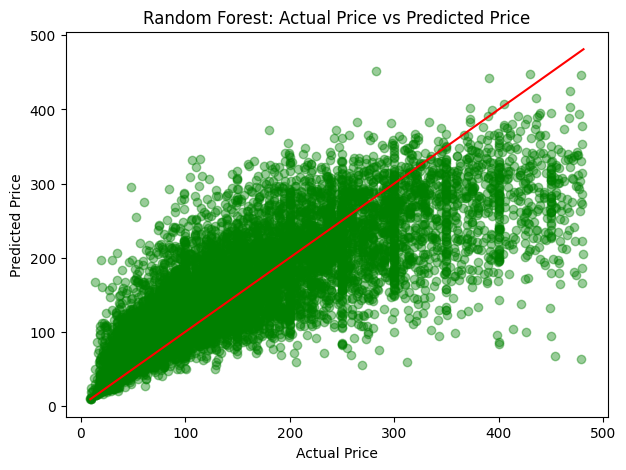

In [30]:
rf = RandomForestRegressor(n_estimators=200, random_state=22, max_depth=None, max_features='sqrt', min_samples_leaf=1, min_samples_split=2)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)
mse_rf = mean_squared_error(y_test, pred_rf)

print("Random Forest MSE:", mse_rf)




# Scatter plot of Actual vs Predicted for Random Forest

plt.figure(figsize=(7,5))
plt.scatter(y_test, pred_rf, alpha=0.4, color='green')

plt.title("Random Forest: Actual Price vs Predicted Price")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

min_val = min(min(y_test), min(pred_rf))
max_val = max(max(y_test), max(pred_rf))
plt.plot([min_val, max_val], [min_val, max_val], color='red')

plt.show()

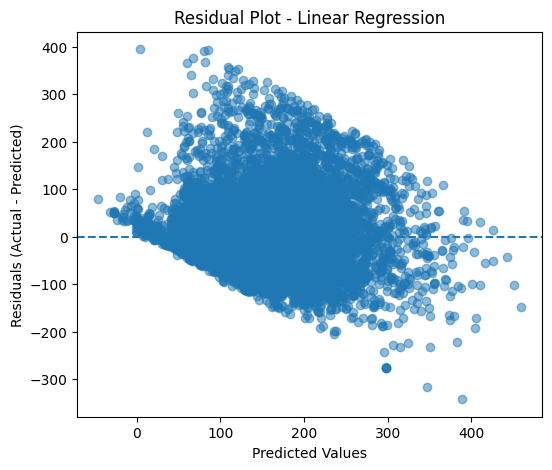

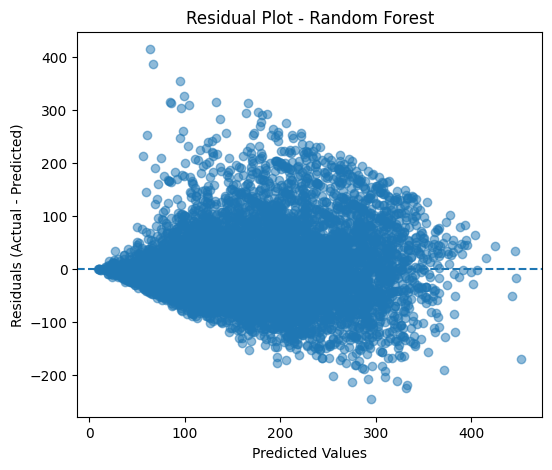

In [31]:
# Residuals
residuals_lr = y_test - pred_lr
residuals_rf = y_test - pred_rf

# -------- Linear Regression Residual Plot -------- #
plt.figure(figsize=(6,5))
plt.scatter(pred_lr, residuals_lr, alpha=0.5)
plt.axhline(y=0, linestyle='--')
plt.title("Residual Plot - Linear Regression")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.show()

# -------- Random Forest Residual Plot -------- #
plt.figure(figsize=(6,5))
plt.scatter(pred_rf, residuals_rf, alpha=0.5)
plt.axhline(y=0, linestyle='--')
plt.title("Residual Plot - Random Forest")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.show()

In [49]:
# Create a double lift chart to compare two models
## Note that this needed a LOT of prompt engineering in ChatGPT, and still needed manual edits.

def plot_double_lift_chart(y_true, y_pred_model1, y_pred_model2,
                           model1_name='Model A', model2_name='Model B',
                           n_bins=10):
    """
    Plots a double lift chart comparing two regression models, 
    where bins are sorted by the ratio of Model 1 to Model 2 predictions.

    Parameters:
    - y_true: Array-like of true continuous values.
    - y_pred_model1: Array-like of predicted values from Model 1.
    - y_pred_model2: Array-like of predicted values from Model 2.
    - model1_name, model2_name: Names to display in the legend.
    - n_bins: Number of quantile bins to use for the lift chart.
    """

    # Build combined dataframe
    data = pd.DataFrame({
        'y_true': y_true,
        'pred1': y_pred_model1,
        'pred2': y_pred_model2
    })

    # Avoid division by zero
    data = data[data['pred2'] != 0]

    # Compute ratio of predictions
    data['ratio'] = data['pred1'] / data['pred2']

    # Sort descending by ratio
    data = data.sort_values(by='ratio', ascending=False)

    # Create quantile bins based on the ratio
    data['bin'] = pd.qcut(data['ratio'], n_bins, labels=False, duplicates='drop')

    # Overall means for normalization
    overall_mean_true = data['y_true'].mean()
    overall_mean_pred1 = data['pred1'].mean()
    overall_mean_pred2 = data['pred2'].mean()

    # Aggregate lift stats for each bin
    lift_data = data.groupby('bin').agg(
        actual_mean=('y_true', 'mean'),
        model1_mean=('pred1', 'mean'),
        model2_mean=('pred2', 'mean')
    ).reset_index()

    # Compute model error in each bin
    lift_data['model1_lift'] = lift_data['model1_mean'] / lift_data['actual_mean']
    lift_data['model2_lift'] = lift_data['model2_mean'] / lift_data['actual_mean']

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(lift_data['bin'], lift_data['model1_lift'], marker='s', linestyle='-', linewidth=2, color='blue', label=f'{model1_name} Predicted Lift')
    plt.plot(lift_data['bin'], lift_data['model2_lift'], marker='s', linestyle='-', linewidth=2, color='green', label=f'{model2_name} Predicted Lift')

    plt.axhline(y=1, color='red', linestyle=':', label='Baseline (Lift = 1)')
    plt.title(f'Double Lift Chart by Ratio of {model1_name} / {model2_name}', fontsize=14)
    plt.xlabel(f'Bins (sorted by {model1_name} / {model2_name} ratio)')
    plt.ylabel('Lift (Mean / Overall Mean)')
    plt.xticks(np.arange(0, lift_data.shape[0]))
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

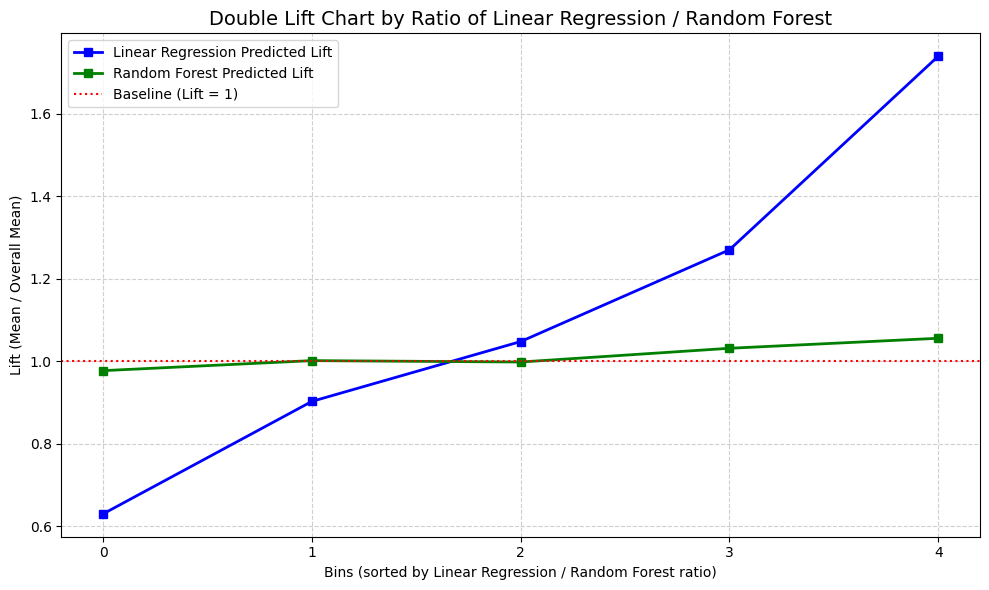

In [50]:
plot_double_lift_chart(y_test, pred_lr, pred_rf,
                           model1_name='Linear Regression', model2_name='Random Forest',
                           n_bins=5)